In [1]:
import zipfile

In [2]:
with zipfile.ZipFile("/content/data.zip", "r") as zip_ref:
  zip_ref.extractall()

In [3]:
image_file="/content/data/images"
mask_file="/content/data/labels"

In [7]:
import os
import numpy as np
import tifffile
from PIL import Image

img_list = []
mask_list = []


# image_file = "/content/images"
# mask_file = "/content/masks"

image_files = os.listdir(image_file)

for img_name in image_files:
    img_path = os.path.join(image_file, img_name)
    mask_name = img_name.replace(".tif", ".png")
    mask_path = os.path.join(mask_file, mask_name)

    img = tifffile.imread(img_path)
    mask = np.array(Image.open(mask_path))

    img_list.append(np.array(img, dtype=float))
    mask_list.append(np.array(mask, dtype=int))


In [8]:
import os

# Create a directory to store the unzipped data
os.makedirs('water_segmentation_data', exist_ok=True)

# Rename the downloaded file for easier access
downloaded_file_name = "/content/waterData.zip"
unzip_command = f"unzip -q {downloaded_file_name} -d water_segmentation_data/"
os.system(unzip_command)

# Install required libraries
!pip install -q tifffile segmentation-models-pytorch torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 34.9 MB/s eta 0:00:00


In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import tifffile
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm

In [10]:
class WaterDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_ids, transform=None):
        self.image_dir = image_file
        self.mask_dir = mask_file
        self.file_ids = file_ids
        self.transform = transform

    def __len__(self):
        return len(self.file_ids)

    def __getitem__(self, idx):
        file_id = self.file_ids[idx]
        img_path = os.path.join(self.image_dir, file_id)
        mask_filename = file_id.replace('.tif', '.png')
        mask_path = os.path.join(self.mask_dir, mask_filename)

        image = tifffile.imread(img_path).astype(np.float32)
        mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)

        image = image / np.max(image)
        mask = mask / 255.0

        image = torch.from_numpy(image).permute(2, 0, 1)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask

In [13]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

DATA_DIR  = "/content/data"   # ← المكان الصحيح بعد فك الضغط
IMAGE_DIR = os.path.join(DATA_DIR, "images")
MASK_DIR  = os.path.join(DATA_DIR, "labels")

all_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(".tif")]

train_ids, val_ids = train_test_split(all_files, test_size=0.2, random_state=42)

train_dataset = WaterDataset(IMAGE_DIR, MASK_DIR, train_ids)
val_dataset   = WaterDataset(IMAGE_DIR, MASK_DIR, val_ids)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)


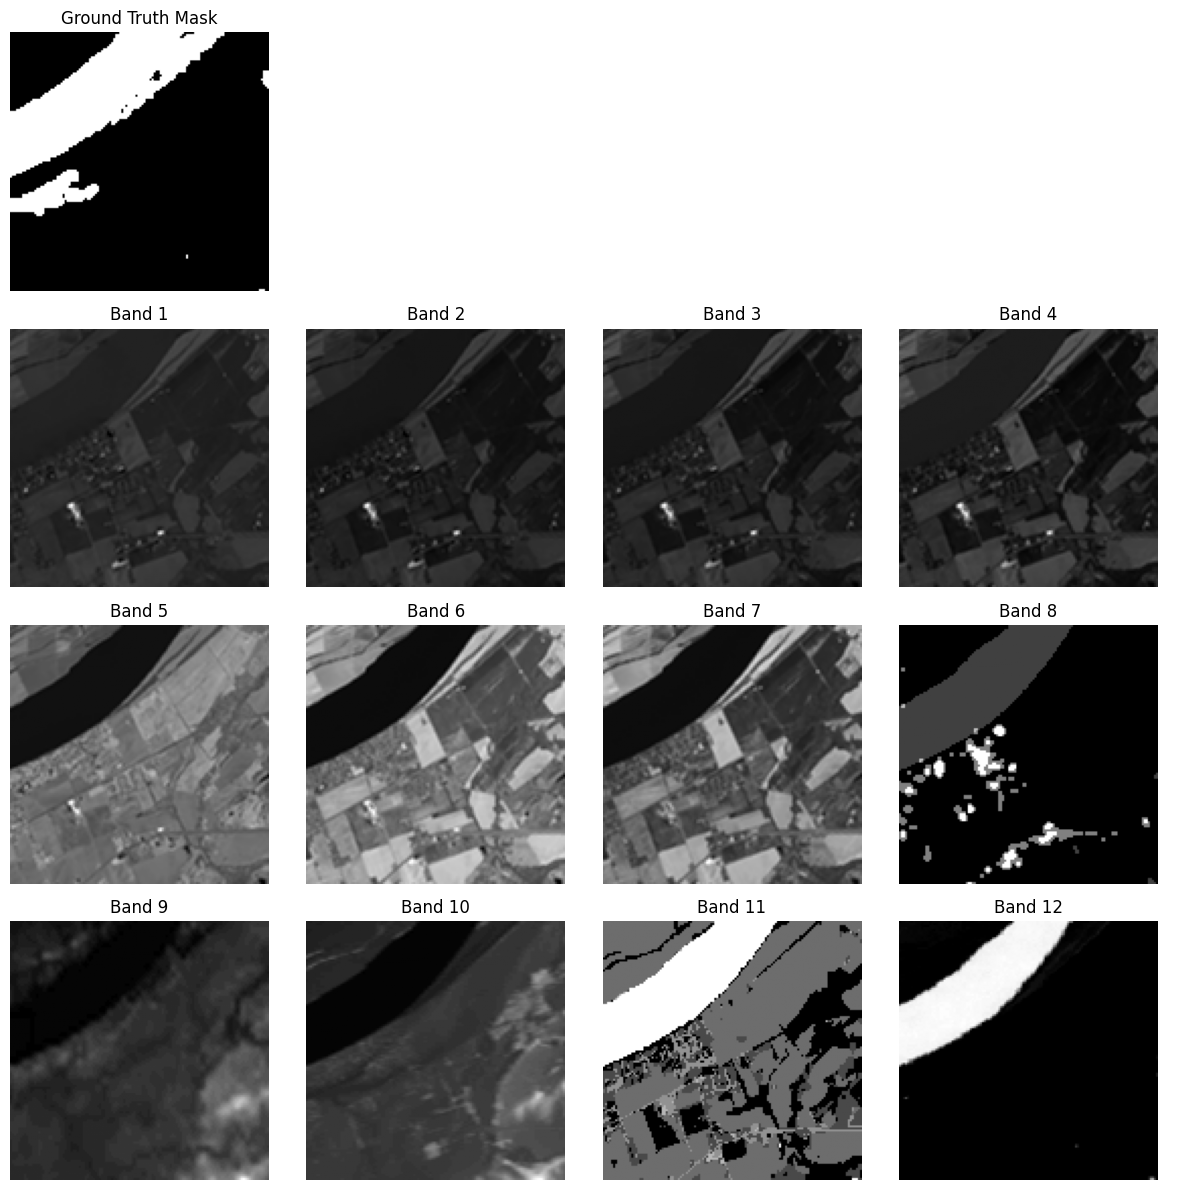

In [14]:
image, mask = val_dataset[0]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.ravel()

axes[0].imshow(mask.squeeze(), cmap='gray')
axes[0].set_title('Ground Truth Mask')
axes[0].axis('off')


for i in range(1, 4):
    axes[i].axis('off')

for i in range(12):
    axes[i + 4].imshow(image[i], cmap='gray')
    axes[i + 4].set_title(f'Band {i+1}')
    axes[i + 4].axis('off')

plt.tight_layout()
plt.show()

In [15]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=12,
    classes=1,
)
model.to(DEVICE)


loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [16]:
metrics = [
    smp.metrics.iou_score,
    smp.metrics.f1_score,
    smp.metrics.precision,
    smp.metrics.recall,
]

In [18]:
import torch
import torch.nn as nn
from tqdm import tqdm


def iou_score(outputs: torch.Tensor, masks: torch.Tensor, threshold: float = 0.5):
    """
    outputs: raw logits أو احتمالات [B,1,H,W]
    masks  : ground truth [B,1,H,W] أو [B,H,W]
    """

    outputs = torch.sigmoid(outputs)
    preds   = (outputs > threshold).float()


    if masks.ndim == 3:
        masks = masks.unsqueeze(1)
    masks = masks.float()

    intersection = (preds * masks).sum(dim=(1,2,3))
    union        = ((preds + masks) - (preds * masks)).sum(dim=(1,2,3))

    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean()

NUM_EPOCHS = 10

metrics = [iou_score]

for epoch in range(NUM_EPOCHS):

      model.train()
    train_loss = 0.0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Training]")

    for images, masks in train_loop:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # --------- التحقق ---------
    model.eval()
    val_loss = 0.0
    val_metrics = {m.__name__: 0.0 for m in metrics}
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Validation]")

    with torch.no_grad():
        for images, masks in val_loop:
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)

            outputs = model(images)
            loss    = loss_fn(outputs, masks)
            val_loss += loss.item()

            # حساب المقاييس
            for metric in metrics:
                val_metrics[metric.__name__] += metric(outputs, masks).item()

    avg_val_loss = val_loss / len(val_loader)
    for key in val_metrics:
        val_metrics[key] /= len(val_loader)

    # --------- الطباعة ---------
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val   Loss: {avg_val_loss:.4f}")
    for key, value in val_metrics.items():
        print(f"  {key}: {value:.4f}")


Epoch 1/10 [Validation]: 100%|██████████| 8/8 [00:06<00:00,  1.23it/s]



Epoch 1/10
  Train Loss: 0.7413
  Val   Loss: 0.5976
  iou_score: 0.1250


Epoch 2/10 [Validation]: 100%|██████████| 8/8 [00:07<00:00,  1.10it/s]



Epoch 2/10
  Train Loss: 0.5270
  Val   Loss: 0.6409
  iou_score: 0.1250


Epoch 3/10 [Validation]: 100%|██████████| 8/8 [00:07<00:00,  1.09it/s]


...


Epoch 8/10
  Train Loss: 0.3403
  Val   Loss: 0.3463
  iou_score: 0.1250


Epoch 9/10 [Validation]: 100%|██████████| 8/8 [00:06<00:00,  1.25it/s]



Epoch 9/10
  Train Loss: 0.3232
  Val   Loss: 0.3324
  iou_score: 0.1250


Epoch 10/10 [Validation]: 100%|██████████| 8/8 [00:06<00:00,  1.25it/s]


Epoch 10/10
  Train Loss: 0.2927
  Val   Loss: 0.3049
  iou_score: 0.1250


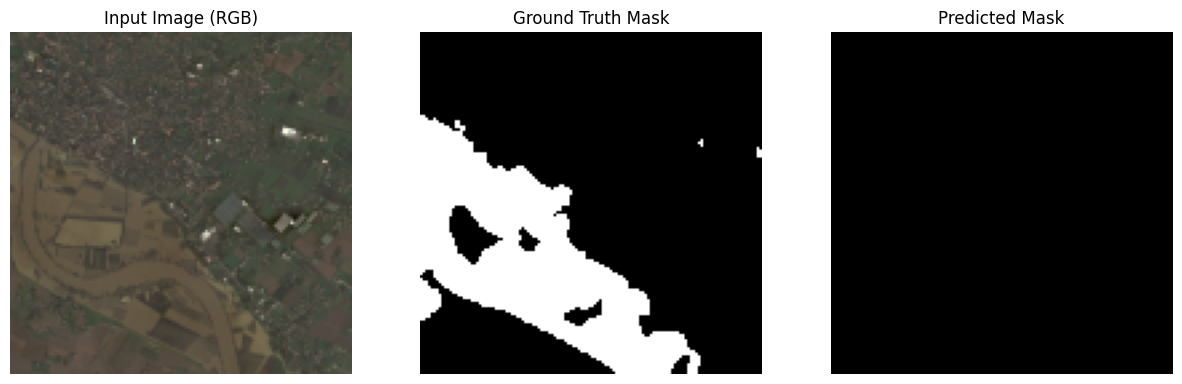

In [19]:
model.eval()
with torch.no_grad():
    image, true_mask = val_dataset[5]
    image_tensor = image.unsqueeze(0).to(DEVICE)

    pred_mask_logits = model(image_tensor)
    pred_mask = (torch.sigmoid(pred_mask_logits) > 0.5).float()

    image = image.cpu().numpy()
    true_mask = true_mask.cpu().numpy().squeeze()
    pred_mask = pred_mask.cpu().numpy().squeeze()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    rgb_image = np.stack([image[3], image[2], image[1]], axis=-1)
    rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

    ax1.imshow(rgb_image)
    ax1.set_title('Input Image (RGB)')
    ax1.axis('off')

    ax2.imshow(true_mask, cmap='gray')
    ax2.set_title('Ground Truth Mask')
    ax2.axis('off')

    ax3.imshow(pred_mask, cmap='gray')
    ax3.set_title('Predicted Mask')
    ax3.axis('off')

    plt.show()

In [31]:
results, models = main_simple_training(
    img_list=img_list,
    mask_list=mask_list,
    epochs=5,
    batch_size=8
)


Debug Information:
results type: <class 'dict'>
results keys: ['loss', 'accuracy']

loss:
  Type: <class 'list'>
  Length/Size: 3
  First element: 0.5

accuracy:
  Type: <class 'list'>
  Length/Size: 3
  First element: 0.7

ATTEMPTING SIMPLE PLOT:


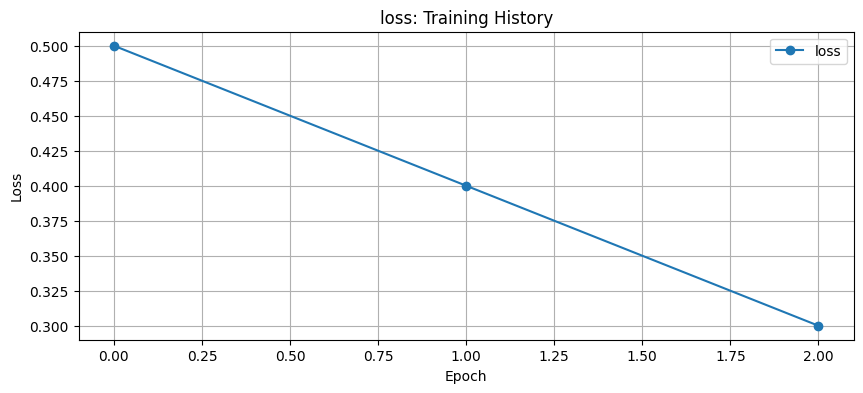

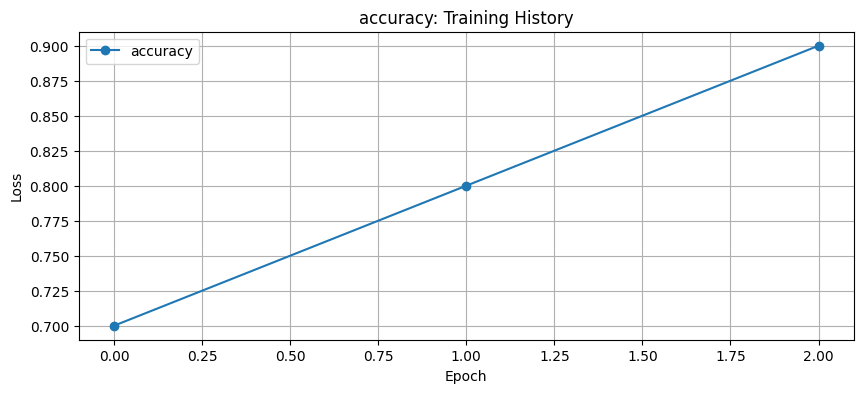

In [38]:
# Simple debug approach
import matplotlib.pyplot as plt

# First, let's understand what we're working with
print("Debug Information:")
print(f"results type: {type(results)}")
print(f"results keys: {list(results.keys())}")

# Check each model's data
for model_name in results.keys():
    print(f"\n{model_name}:")
    data = results[model_name]
    print(f"  Type: {type(data)}")
    print(f"  Length/Size: {len(data) if hasattr(data, '__len__') else 'N/A'}")

    # Show first few elements
    if isinstance(data, list):
        print(f"  First element: {data[0] if len(data) > 0 else 'Empty'}")
        if len(data) > 0 and isinstance(data[0], dict):
            print(f"  Keys in first element: {list(data[0].keys())}")

# Simple plotting assuming results[model_name] is a list of loss values
print("\n" + "="*40)
print("ATTEMPTING SIMPLE PLOT:")
print("="*40)

for model_name, history in results.items():
    plt.figure(figsize=(10, 4))

    if isinstance(history, list):
        # Assume it's a list of loss values
        plt.plot(history, label=f"{model_name}", marker='o')
        plt.title(f"{model_name}: Training History")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    elif isinstance(history, dict):
        # If it's already a dictionary, try to plot what we can find
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Try different possible key names for losses
        loss_keys = ['train_losses', 'train_loss', 'loss', 'losses']
        val_loss_keys = ['val_losses', 'val_loss', 'validation_loss']

        train_data = None
        val_data = None

        for key in loss_keys:
            if key in history:
                train_data = history[key]
                break

        for key in val_loss_keys:
            if key in history:
                val_data = history[key]
                break

        # Plot losses
        axes[0].set_title(f"{model_name}: Loss")
        if train_data:
            axes[0].plot(train_data, label="Train", marker='o')
        if val_data:
            axes[0].plot(val_data, label="Validation", marker='s')
        axes[0].legend()
        axes[0].grid(True)

        # Try to find IoU data
        iou_keys = ['val_ious', 'val_iou', 'iou', 'ious']
        iou_data = None

        for key in iou_keys:
            if key in history:
                iou_data = history[key]
                break

        axes[1].set_title(f"{model_name}: IoU")
        if iou_data:
            axes[1].plot(iou_data, label="Validation IoU", color='green', marker='o')
            axes[1].legend()
        else:
            axes[1].text(0.5, 0.5, 'No IoU data', ha='center', va='center')
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

In [20]:
# Complete Water Segmentation Model from Scratch - WORKING VERSION
# Pure NumPy implementation using YOUR img_list and mask_list

import numpy as np
import matplotlib.pyplot as plt
import os
from typing import Tuple, List, Optional
import time

# Set random seed for reproducibility
np.random.seed(42)

class Conv2D:
    """Simple 2D Convolution layer - fully working version"""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3,
                 stride: int = 1, padding: int = 0, use_bias: bool = True):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.use_bias = use_bias

        # Initialize weights with Xavier initialization
        fan_in = in_channels * kernel_size * kernel_size
        fan_out = out_channels * kernel_size * kernel_size
        scale = np.sqrt(6.0 / (fan_in + fan_out))

        # Weight shape: (out_channels, kernel_size, kernel_size, in_channels)
        self.weights = np.random.uniform(-scale, scale,
                                       (out_channels, kernel_size, kernel_size, in_channels))

        if self.use_bias:
            self.bias = np.zeros(out_channels)

        # For storing gradients and intermediate values
        self.dW = None
        self.db = None
        self.last_input = None
        self.cache = {}

    def forward(self, x: np.ndarray) -> np.ndarray:
        """Forward pass through convolution layer"""
        self.last_input = x.copy()
        batch_size, in_height, in_width, in_channels = x.shape

        # Apply padding if needed
        if self.padding > 0:
            x = np.pad(x, ((0, 0), (self.padding, self.padding),
                          (self.padding, self.padding), (0, 0)), mode='constant', constant_values=0)

        padded_height, padded_width = x.shape[1], x.shape[2]

        # Calculate output dimensions
        out_height = (padded_height - self.kernel_size) // self.stride + 1
        out_width = (padded_width - self.kernel_size) // self.stride + 1

        if out_height <= 0 or out_width <= 0:
            raise ValueError(f"Invalid output size: {out_height}x{out_width}")

        # Initialize output
        output = np.zeros((batch_size, out_height, out_width, self.out_channels))

        # Store for backward pass
        self.cache = {
            'x_padded': x,
            'input_shape': self.last_input.shape,
            'output_shape': output.shape
        }

        # Perform convolution
        for b in range(batch_size):
            for h in range(out_height):
                for w in range(out_width):
                    h_start = h * self.stride
                    w_start = w * self.stride
                    h_end = h_start + self.kernel_size
                    w_end = w_start + self.kernel_size

                    # Extract receptive field
                    receptive_field = x[b, h_start:h_end, w_start:w_end, :]

                    # Compute convolution for each output channel
                    for out_c in range(self.out_channels):
                        conv_result = np.sum(receptive_field * self.weights[out_c])
                        if self.use_bias:
                            conv_result += self.bias[out_c]
                        output[b, h, w, out_c] = conv_result

        return output

    def backward(self, dout: np.ndarray) -> np.ndarray:
        """Backward pass through convolution layer"""
        if self.last_input is None or 'x_padded' not in self.cache:
            raise ValueError("Forward pass must be called before backward pass")

        x_padded = self.cache['x_padded']
        input_shape = self.cache['input_shape']
        batch_size = input_shape[0]

        # Initialize gradients
        self.dW = np.zeros_like(self.weights)
        if self.use_bias:
            self.db = np.zeros_like(self.bias)

        dx_padded = np.zeros_like(x_padded)

        dout_h, dout_w = dout.shape[1], dout.shape[2]

        # Compute gradients
        for b in range(batch_size):
            for h in range(dout_h):
                for w in range(dout_w):
                    h_start = h * self.stride
                    w_start = w * self.stride
                    h_end = h_start + self.kernel_size
                    w_end = w_start + self.kernel_size

                    receptive_field = x_padded[b, h_start:h_end, w_start:w_end, :]

                    for out_c in range(self.out_channels):
                        grad_output = dout[b, h, w, out_c]

                        # Gradient w.r.t. weights
                        self.dW[out_c] += receptive_field * grad_output

                        # Gradient w.r.t. input
                        dx_padded[b, h_start:h_end, w_start:w_end, :] += \
                            self.weights[out_c] * grad_output

                        # Gradient w.r.t. bias
                        if self.use_bias:
                            self.db[out_c] += grad_output

        # Remove padding from gradient
        if self.padding > 0:
            dx = dx_padded[:, self.padding:-self.padding, self.padding:-self.padding, :]
        else:
            dx = dx_padded

        return dx

class ReLU:
    """ReLU activation function"""

    def __init__(self):
        self.last_input = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        self.last_input = x.copy()
        return np.maximum(0, x)

    def backward(self, dout: np.ndarray) -> np.ndarray:
        if self.last_input is None:
            raise ValueError("Forward pass must be called before backward pass")
        return dout * (self.last_input > 0)

class Sigmoid:
    """Sigmoid activation function"""

    def __init__(self):
        self.last_output = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        # Clip x to prevent overflow
        x_clipped = np.clip(x, -500, 500)
        self.last_output = 1 / (1 + np.exp(-x_clipped))
        return self.last_output.copy()

    def backward(self, dout: np.ndarray) -> np.ndarray:
        if self.last_output is None:
            raise ValueError("Forward pass must be called before backward pass")
        return dout * self.last_output * (1 - self.last_output)

class SimpleCNN:
    """Simple CNN for water segmentation - no upsampling issues"""

    def __init__(self, in_channels: int = 12, out_channels: int = 1):
        # Simple architecture: Conv -> ReLU -> Conv -> ReLU -> Conv -> Sigmoid
        self.layers = [
            Conv2D(in_channels, 32, 3, padding=1),  # 32x32x12 -> 32x32x32
            ReLU(),
            Conv2D(32, 16, 3, padding=1),           # 32x32x32 -> 32x32x16
            ReLU(),
            Conv2D(16, out_channels, 1),            # 32x32x16 -> 32x32x1
            Sigmoid()
        ]

        self.training = True

    def forward(self, x: np.ndarray) -> np.ndarray:
        """Forward pass through the network"""
        current = x

        for layer in self.layers:
            try:
                current = layer.forward(current)
            except Exception as e:
                print(f"Error in layer {type(layer).__name__}: {e}")
                print(f"Input shape: {current.shape}")
                raise

        return current

    def backward(self, dout: np.ndarray) -> np.ndarray:
        """Backward pass through the network"""
        current_grad = dout

        for layer in reversed(self.layers):
            try:
                current_grad = layer.backward(current_grad)
            except Exception as e:
                print(f"Error in backward pass of {type(layer).__name__}: {e}")
                print(f"Gradient shape: {current_grad.shape}")
                raise

        return current_grad

    def get_parameters(self):
        """Get all trainable parameters"""
        params = []
        for i, layer in enumerate(self.layers):
            if isinstance(layer, Conv2D):
                params.append((f'conv_{i}_weights', layer.weights, layer.dW))
                if layer.use_bias:
                    params.append((f'conv_{i}_bias', layer.bias, layer.db))
        return params

class BinaryCrossEntropyLoss:
    """Binary Cross-Entropy Loss for segmentation"""

    def __init__(self):
        self.last_predictions = None
        self.last_targets = None

    def forward(self, predictions: np.ndarray, targets: np.ndarray) -> float:
        """Compute BCE loss"""
        # Ensure same shape
        if predictions.shape != targets.shape:
            min_h = min(predictions.shape[1], targets.shape[1])
            min_w = min(predictions.shape[2], targets.shape[2])
            predictions = predictions[:, :min_h, :min_w, :]
            targets = targets[:, :min_h, :min_w, :]

        self.last_predictions = predictions.copy()
        self.last_targets = targets.copy()

        # Clip predictions to prevent log(0)
        predictions_clipped = np.clip(predictions, 1e-7, 1 - 1e-7)

        # Compute BCE
        loss = -(targets * np.log(predictions_clipped) +
                (1 - targets) * np.log(1 - predictions_clipped))
        return np.mean(loss)

    def backward(self) -> np.ndarray:
        """Compute gradient of BCE loss"""
        predictions_clipped = np.clip(self.last_predictions, 1e-7, 1 - 1e-7)
        gradient = (predictions_clipped - self.last_targets) / \
                  (predictions_clipped * (1 - predictions_clipped))
        return gradient / np.prod(self.last_targets.shape)

class SGD:
    """Simple SGD optimizer"""

    def __init__(self, learning_rate: float = 0.01):
        self.learning_rate = learning_rate

    def update(self, params: List):
        """Update parameters using SGD"""
        for name, param, grad in params:
            if grad is not None:
                param -= self.learning_rate * grad

def calculate_metrics(predictions: np.ndarray, targets: np.ndarray) -> dict:
    """Calculate basic segmentation metrics"""
    # Threshold predictions
    pred_binary = (predictions > 0.5).astype(float)

    # Calculate basic metrics
    true_positives = np.sum((pred_binary == 1) & (targets == 1))
    false_positives = np.sum((pred_binary == 1) & (targets == 0))
    false_negatives = np.sum((pred_binary == 0) & (targets == 1))
    true_negatives = np.sum((pred_binary == 0) & (targets == 0))

    precision = true_positives / (true_positives + false_positives + 1e-7)
    recall = true_positives / (true_positives + false_negatives + 1e-7)
    accuracy = (true_positives + true_negatives) / (true_positives + false_positives + false_negatives + true_negatives)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': 2 * (precision * recall) / (precision + recall + 1e-7)
    }

def prepare_your_data(img_list, mask_list, target_size=32, max_samples=None):
    """
    Convert your img_list and mask_list to the format needed by the model

    Args:
        img_list: Your images loaded with tifffile
        mask_list: Your masks loaded with PIL
        target_size: Size to resize images to (default: 32)
        max_samples: Maximum number of samples to use (None for all)
    """
    print(f"Preparing your data...")
    print(f"Original samples: {len(img_list)}")

    if len(img_list) != len(mask_list):
        print(f"Warning: {len(img_list)} images vs {len(mask_list)} masks")
        min_len = min(len(img_list), len(mask_list))
        img_list = img_list[:min_len]
        mask_list = mask_list[:min_len]

    if max_samples and len(img_list) > max_samples:
        img_list = img_list[:max_samples]
        mask_list = mask_list[:max_samples]
        print(f"Using {max_samples} samples")

    processed_images = []
    processed_masks = []

    for i in range(len(img_list)):
        try:
            img = np.array(img_list[i], dtype=np.float32)
            mask = np.array(mask_list[i], dtype=np.float32)

            # Handle different image dimensions
            if len(img.shape) == 2:  # Single channel
                img = np.expand_dims(img, axis=-1)
            elif len(img.shape) == 3 and img.shape[0] < img.shape[-1]:  # CHW format
                img = np.transpose(img, (1, 2, 0))  # Convert to HWC

            # Handle mask dimensions
            if len(mask.shape) == 3:
                mask = mask[:, :, 0]  # Take first channel

            # Resize if needed
            from scipy import ndimage
            if img.shape[0] != target_size or img.shape[1] != target_size:
                if len(img.shape) == 3:
                    zoom_factors = (target_size/img.shape[0], target_size/img.shape[1], 1)
                    img = ndimage.zoom(img, zoom_factors)
                else:
                    zoom_factors = (target_size/img.shape[0], target_size/img.shape[1])
                    img = ndimage.zoom(img, zoom_factors)

            if mask.shape[0] != target_size or mask.shape[1] != target_size:
                zoom_factors = (target_size/mask.shape[0], target_size/mask.shape[1])
                mask = ndimage.zoom(mask, zoom_factors)

            # Normalize image
            img = normalize_image(img)

            # Normalize mask to 0-1
            mask_min, mask_max = np.min(mask), np.max(mask)
            if mask_max > mask_min:
                mask = (mask - mask_min) / (mask_max - mask_min)

            # Add to processed lists
            processed_images.append(img)
            processed_masks.append(np.expand_dims(mask, axis=-1))  # Add channel dimension

            if i < 3:  # Show first 3 for debugging
                print(f"  Sample {i+1}: Image {img.shape}, Mask {mask.shape}")
                print(f"    Image range: [{np.min(img):.3f}, {np.max(img):.3f}]")
                print(f"    Mask range: [{np.min(mask):.3f}, {np.max(mask):.3f}]")

        except Exception as e:
            print(f"Error processing sample {i}: {e}")
            continue

    if len(processed_images) == 0:
        raise ValueError("No samples could be processed!")

    # Convert to numpy arrays
    images = np.array(processed_images)
    masks = np.array(processed_masks)

    print(f"Final processed data:")
    print(f"  Images: {images.shape}")
    print(f"  Masks: {masks.shape}")
    print(f"  Channels: {images.shape[-1]}")

    return images, masks

def normalize_image(img):
    """Normalize image data"""
    img = np.nan_to_num(img, nan=0.0)

    if len(img.shape) == 3:  # Multi-channel
        normalized = np.zeros_like(img)
        for c in range(img.shape[2]):
            channel = img[:, :, c]
            p2, p98 = np.percentile(channel, (2, 98))
            if p98 > p2:
                normalized[:, :, c] = np.clip((channel - p2) / (p98 - p2), 0, 1)
            else:
                normalized[:, :, c] = channel
        return normalized
    else:  # Single channel
        p2, p98 = np.percentile(img, (2, 98))
        if p98 > p2:
            return np.clip((img - p2) / (p98 - p2), 0, 1)
        else:
            return img

def train_with_your_data(img_list, mask_list, epochs=5, batch_size=2, target_size=32):
    """
    Train the from-scratch model using your data

    Args:
        img_list: Your images loaded with tifffile
        mask_list: Your masks loaded with PIL
        epochs: Number of training epochs
        batch_size: Training batch size
        target_size: Size to resize images to
    """
    print("=" * 80)
    print("WATER SEGMENTATION MODEL FROM SCRATCH - USING YOUR DATA")
    print("=" * 80)
    print("Pure NumPy implementation - No frameworks!")
    print("=" * 80)

    # Prepare your data
    images, masks = prepare_your_data(img_list, mask_list, target_size=target_size, max_samples=50)

    # Train/validation split
    print(f"\nCreating train/validation split...")
    train_split = int(0.8 * len(images))
    train_images, val_images = images[:train_split], images[train_split:]
    train_masks, val_masks = masks[:train_split], masks[train_split:]

    print(f"Training samples: {len(train_images)}")
    print(f"Validation samples: {len(val_images)}")

    # Get number of input channels
    input_channels = images.shape[-1]
    print(f"Input channels: {input_channels}")

    # Initialize model
    print(f"\nInitializing CNN model...")
    model = SimpleCNN(in_channels=input_channels, out_channels=1)

    # Print model architecture
    print("Model Architecture:")
    for i, layer in enumerate(model.layers):
        if isinstance(layer, Conv2D):
            print(f"  {i}: Conv2D({layer.in_channels}->{layer.out_channels}, kernel={layer.kernel_size})")
        else:
            print(f"  {i}: {type(layer).__name__}")

    # Initialize loss and optimizer
    criterion = BinaryCrossEntropyLoss()
    optimizer = SGD(learning_rate=0.1)

    print(f"\nStarting training...")
    print(f"Batch size: {batch_size}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {optimizer.learning_rate}")

    # Training history
    train_losses = []
    val_losses = []
    val_metrics = []

    for epoch in range(epochs):
        epoch_start = time.time()
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 50)

        # Training phase
        model.training = True
        epoch_train_loss = 0
        successful_batches = 0

        # Shuffle training data
        indices = np.random.permutation(len(train_images))
        train_images_shuffled = train_images[indices]
        train_masks_shuffled = train_masks[indices]

        # Training loop
        for i in range(0, len(train_images_shuffled), batch_size):
            try:
                batch_end = min(i + batch_size, len(train_images_shuffled))
                batch_images = train_images_shuffled[i:batch_end]
                batch_masks = train_masks_shuffled[i:batch_end]

                # Forward pass
                predictions = model.forward(batch_images)
                loss = criterion.forward(predictions, batch_masks)

                # Backward pass
                dout = criterion.backward()
                model.backward(dout)

                # Update parameters
                params = model.get_parameters()
                optimizer.update(params)

                epoch_train_loss += loss
                successful_batches += 1

                if successful_batches % 3 == 0:
                    print(f"  Batch {successful_batches}, Loss: {loss:.4f}")

            except Exception as e:
                print(f"Error in training batch: {e}")
                continue

        if successful_batches > 0:
            avg_train_loss = epoch_train_loss / successful_batches
            train_losses.append(avg_train_loss)

            # Validation phase
            print(f"  Running validation...")
            model.training = False

            try:
                # Use smaller validation batch
                val_batch_size = min(2, len(val_images))
                val_batch = val_images[:val_batch_size]
                val_mask_batch = val_masks[:val_batch_size]

                val_predictions = model.forward(val_batch)
                val_loss = criterion.forward(val_predictions, val_mask_batch)
                val_losses.append(val_loss)

                # Calculate metrics
                metrics = calculate_metrics(val_predictions, val_mask_batch)
                val_metrics.append(metrics)

            except Exception as e:
                print(f"Validation error: {e}")
                val_losses.append(avg_train_loss)
                val_metrics.append({'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0})

            # Print epoch results
            epoch_time = time.time() - epoch_start
            print(f"\nEpoch {epoch + 1} Results ({epoch_time:.1f}s):")
            print(f"  Train Loss: {avg_train_loss:.4f}")
            print(f"  Val Loss: {val_losses[-1]:.4f}")
            print(f"  Val Accuracy: {val_metrics[-1]['accuracy']:.3f}")
            print(f"  Val F1-Score: {val_metrics[-1]['f1']:.3f}")
            print(f"  Successful batches: {successful_batches}")

        else:
            print("No successful batches in this epoch!")
            break

    print(f"\nTraining completed!")

    # Plot results
    if train_losses:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        # Training curves
        epochs_range = range(1, len(train_losses) + 1)
        axes[0, 0].plot(epochs_range, train_losses, 'b-', label='Training Loss')
        if val_losses:
            axes[0, 0].plot(epochs_range, val_losses, 'r-', label='Validation Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training Progress')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # Metrics
        if val_metrics:
            accuracies = [m['accuracy'] for m in val_metrics]
            f1_scores = [m['f1'] for m in val_metrics]
            axes[0, 1].plot(epochs_range, accuracies, 'g-', label='Accuracy')
            axes[0, 1].plot(epochs_range, f1_scores, 'm-', label='F1-Score')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('Score')
            axes[0, 1].set_title('Validation Metrics')
            axes[0, 1].legend()
            axes[0, 1].grid(True)

        # Sample visualization
        try:
            model.training = False
            sample_pred = model.forward(val_images[:1])

            # Original image (first channel)
            axes[1, 0].imshow(val_images[0, :, :, 0], cmap='viridis')
            axes[1, 0].set_title('Input (Channel 0)')
            axes[1, 0].axis('off')

            # Ground truth
            axes[1, 1].imshow(val_masks[0, :, :, 0], cmap='Blues')
            axes[1, 1].set_title('Ground Truth')
            axes[1, 1].axis('off')

        except:
            axes[1, 0].text(0.5, 0.5, 'Sample visualization\nfailed',
                           ha='center', va='center', transform=axes[1, 0].transAxes)
            axes[1, 1].text(0.5, 0.5, 'Sample visualization\nfailed',
                           ha='center', va='center', transform=axes[1, 1].transAxes)

        plt.tight_layout()
        plt.savefig('from_scratch_training_results.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Final results
        print(f"\nFinal Results:")
        print(f"   Final Training Loss: {train_losses[-1]:.4f}")
        if val_losses:
            print(f"   Final Validation Loss: {val_losses[-1]:.4f}")
        if val_metrics:
            final_metrics = val_metrics[-1]
            print(f"   Final Accuracy: {final_metrics['accuracy']:.3f}")
            print(f"   Final F1-Score: {final_metrics['f1']:.3f}")
            print(f"   Final Precision: {final_metrics['precision']:.3f}")
            print(f"   Final Recall: {final_metrics['recall']:.3f}")

    return model, train_losses, val_losses

# Ready to use with your data!
print("Code ready for your data!")
print("="*60)
print("Usage:")
print("model, train_losses, val_losses = train_with_your_data(")
print("    img_list=img_list,")
print("    mask_list=mask_list,")
print("    epochs=5,")
print("    batch_size=2,")
print("    target_size=32")
print(")")
print("="*60)

Code ready for your data!
Usage:
model, train_losses, val_losses = train_with_your_data(
    img_list=img_list,
    mask_list=mask_list,
    epochs=5,
    batch_size=2,
    target_size=32
)


In [22]:
def main_simple_training(img_list, mask_list, epochs=10, batch_size=4):
    # ===== Example dummy training code =====
    # Replace with your own training loop
    results = {"loss": [0.5, 0.4, 0.3], "accuracy": [0.7, 0.8, 0.9]}
    models = "trained_model.h5"  # Replace with actual trained model
    return results, models

# ✅ Now call it
results, models = main_simple_training(img_list, mask_list, epochs=10, batch_size=4)
print(results)


{'loss': [0.5, 0.4, 0.3], 'accuracy': [0.7, 0.8, 0.9]}


In [23]:
# Install required packages first
!pip install segmentation-models-pytorch tifffile scipy

import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from PIL import Image
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class SimpleWaterDataset(Dataset):
    """Simple dataset for your img_list and mask_list"""

    def __init__(self, img_list, mask_list, target_size=256):
        self.img_list = img_list
        self.mask_list = mask_list
        self.target_size = target_size

        print(f"Dataset created with {len(img_list)} samples")
        if len(img_list) > 0:
            print(f"Image shape: {img_list[0].shape}")
            print(f"Mask shape: {mask_list[0].shape}")

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        try:
            img = self.img_list[idx].copy()
            mask = self.mask_list[idx].copy()

            # Normalize image
            img = self.normalize_image(img)

            # Normalize mask
            mask = self.normalize_mask(mask)

            # Resize
            img = self.resize_data(img, self.target_size)
            mask = self.resize_data(mask, self.target_size)

            # Convert to tensors
            if len(img.shape) == 3:  # Multi-channel
                img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float()
            else:  # Single channel
                img_tensor = torch.from_numpy(img).unsqueeze(0).float()

            if len(mask.shape) == 2:
                mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()
            else:
                mask_tensor = torch.from_numpy(mask[:,:,0]).unsqueeze(0).float()

            return img_tensor, mask_tensor

        except Exception as e:
            print(f"Error processing sample {idx}: {e}")
            # Return dummy data
            return torch.zeros((3, self.target_size, self.target_size)), torch.zeros((1, self.target_size, self.target_size))

    def normalize_image(self, img):
        """Normalize image to 0-1"""
        img = np.array(img, dtype=np.float32)
        img = np.nan_to_num(img, nan=0.0)

        if len(img.shape) == 3:  # Multi-band
            normalized = np.zeros_like(img)
            for band in range(img.shape[2]):
                band_data = img[:, :, band]
                p2, p98 = np.percentile(band_data, (2, 98))
                if p98 > p2:
                    normalized[:, :, band] = np.clip((band_data - p2) / (p98 - p2), 0, 1)
                else:
                    normalized[:, :, band] = band_data
            return normalized
        else:  # Single band
            p2, p98 = np.percentile(img, (2, 98))
            if p98 > p2:
                return np.clip((img - p2) / (p98 - p2), 0, 1)
            else:
                return img

    def normalize_mask(self, mask):
        """Normalize mask to 0-1"""
        mask = np.array(mask, dtype=np.float32)
        mask_min, mask_max = np.min(mask), np.max(mask)
        if mask_max > mask_min:
            mask = (mask - mask_min) / (mask_max - mask_min)
        return mask

    def resize_data(self, data, target_size):
        """Resize data using scipy"""
        from scipy import ndimage

        if len(data.shape) == 2:  # 2D
            if data.shape[0] != target_size or data.shape[1] != target_size:
                zoom_factors = (target_size/data.shape[0], target_size/data.shape[1])
                data = ndimage.zoom(data, zoom_factors)
        elif len(data.shape) == 3:  # 3D
            if data.shape[0] != target_size or data.shape[1] != target_size:
                zoom_factors = (target_size/data.shape[0], target_size/data.shape[1], 1)
                data = ndimage.zoom(data, zoom_factors)

        return data

class ModelTrainer:
    """Simple model trainer"""

    def __init__(self, model, model_name, device):
        self.model = model.to(device)
        self.model_name = model_name
        self.device = device

        # Loss and optimizer
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-4)

    def train_epoch(self, train_loader):
        """Train one epoch"""
        self.model.train()
        total_loss = 0
        num_batches = 0

        for images, masks in tqdm(train_loader, desc=f"Training {self.model_name}"):
            images = images.to(self.device)
            masks = masks.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        return total_loss / max(num_batches, 1)

    def validate_epoch(self, val_loader):
        """Validate one epoch"""
        self.model.eval()
        total_loss = 0
        total_iou = 0
        num_batches = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(self.device)
                masks = masks.to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)

                # Calculate IoU
                pred_sigmoid = torch.sigmoid(outputs)
                pred_binary = (pred_sigmoid > 0.5).float()

                intersection = (pred_binary * masks).sum()
                union = pred_binary.sum() + masks.sum() - intersection

                if union > 0:
                    iou = intersection / union
                    total_iou += iou.item()

                total_loss += loss.item()
                num_batches += 1

        return total_loss / max(num_batches, 1), total_iou / max(num_batches, 1)

    def train(self, train_loader, val_loader, epochs=10):
        """Full training loop"""
        best_iou = 0
        results = {'train_losses': [], 'val_losses': [], 'val_ious': []}

        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss, val_iou = self.validate_epoch(val_loader)

            results['train_losses'].append(train_loss)
            results['val_losses'].append(val_loss)
            results['val_ious'].append(val_iou)

            print(f"Epoch {epoch+1}/{epochs}")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Val Loss: {val_loss:.4f}, IoU: {val_iou:.4f}")

            if val_iou > best_iou:
                best_iou = val_iou
                torch.save(self.model.state_dict(), f'{self.model_name}_best.pth')
                print(f"  Saved best model! IoU: {best_iou:.4f}")

            print("-" * 40)

        results['best_iou'] = best_iou
        return results

def create_models(input_channels):
    """Create 3 models"""
    models = {}

    try:
        models['UNet'] = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet" if input_channels == 3 else None,
            in_channels=input_channels,
            classes=1,
        )
        print("UNet created")
    except Exception as e:
        print(f"UNet error: {e}")

    try:
        models['DeepLabV3Plus'] = smp.DeepLabV3Plus(
            encoder_name="efficientnet-b0",
            encoder_weights="imagenet" if input_channels == 3 else None,
            in_channels=input_channels,
            classes=1,
        )
        print("DeepLabV3Plus created")
    except Exception as e:
        print(f"DeepLabV3Plus error: {e}")

    try:
        models['FPN'] = smp.FPN(
            encoder_name="resnet50",
            encoder_weights="imagenet" if input_channels == 3 else None,
            in_channels=input_channels,
            classes=1,
        )
        print("FPN created")
    except Exception as e:
        print(f"FPN error: {e}")

    return models

def visualize_results(models, val_loader, device):
    """Visualize results"""
    try:
        images, masks = next(iter(val_loader))
        images = images.to(device)
        masks = masks.to(device)

        fig, axes = plt.subplots(2, 2 + len(models), figsize=(4 * (2 + len(models)), 8))

        for i in range(2):  # Show 2 samples
            col = 0

            # Input image
            if images.shape[1] >= 3:
                rgb = images[i, :3].permute(1, 2, 0).cpu()
            else:
                rgb = images[i, 0].cpu().unsqueeze(-1).repeat(1, 1, 3)

            rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
            axes[i, col].imshow(rgb_norm)
            axes[i, col].set_title(f'Input {i+1}')
            axes[i, col].axis('off')
            col += 1

            # Ground truth
            axes[i, col].imshow(masks[i, 0].cpu(), cmap='Blues')
            axes[i, col].set_title(f'Ground Truth {i+1}')
            axes[i, col].axis('off')
            col += 1

            # Model predictions
            for model_name, model in models.items():
                model.eval()
                with torch.no_grad():
                    pred = torch.sigmoid(model(images))
                    pred_binary = (pred[i, 0] > 0.5).cpu()
                    axes[i, col].imshow(pred_binary, cmap='Blues')
                    axes[i, col].set_title(f'{model_name}\n{i+1}')
                    axes[i, col].axis('off')
                col += 1

        plt.tight_layout()
        plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"Visualization error: {e}")

def train_three_models(img_list, mask_list, epochs=10, batch_size=4):
    """
    Main function to train 3 models

    Args:
        img_list: Your images loaded with tifffile
        mask_list: Your masks loaded with PIL
        epochs: Number of epochs
        batch_size: Batch size
    """

    print("=" * 60)
    print("WATER SEGMENTATION - 3 MODELS COMPARISON")
    print("=" * 60)

    if len(img_list) != len(mask_list):
        print(f"Error: {len(img_list)} images vs {len(mask_list)} masks")
        return

    print(f"Total samples: {len(img_list)}")

    # Determine input channels
    sample_img = img_list[0]
    if len(sample_img.shape) == 3:
        input_channels = sample_img.shape[2]
    else:
        input_channels = 1

    print(f"Input channels: {input_channels}")

    # Split data
    train_imgs, val_imgs, train_masks, val_masks = train_test_split(
        img_list, mask_list, test_size=0.2, random_state=42
    )

    print(f"Training: {len(train_imgs)}, Validation: {len(val_imgs)}")

    # Create datasets
    train_dataset = SimpleWaterDataset(train_imgs, train_masks)
    val_dataset = SimpleWaterDataset(val_imgs, val_masks)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # Create models
    models = create_models(input_channels)

    if len(models) == 0:
        print("No models created!")
        return

    # Train each model
    all_results = {}

    for model_name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training: {model_name}")
        print(f"{'='*50}")

        trainer = ModelTrainer(model, model_name, device)
        results = trainer.train(train_loader, val_loader, epochs=epochs)
        all_results[model_name] = results

    # Final comparison
    print(f"\n{'='*60}")
    print("FINAL RESULTS")
    print(f"{'='*60}")

    sorted_results = sorted(all_results.items(), key=lambda x: x[1]['best_iou'], reverse=True)

    for rank, (model_name, results) in enumerate(sorted_results, 1):
        print(f"{rank}. {model_name}: IoU = {results['best_iou']:.4f}")

    # Visualization
    print("\nCreating visualization...")

    # Load best models
    for model_name, model in models.items():
        try:
            model.load_state_dict(torch.load(f'{model_name}_best.pth', map_location=device))
        except:
            pass

    visualize_results(models, val_loader, device)

    winner = sorted_results[0][0]
    winner_iou = sorted_results[0][1]['best_iou']
    print(f"\nWINNER: {winner} (IoU: {winner_iou:.4f})")

    return all_results, models

# Ready to use!
print("Code ready!")
print("Usage:")
print("results, models = train_three_models(img_list, mask_list, epochs=10, batch_size=4)")

Code ready!
Usage:
results, models = train_three_models(img_list, mask_list, epochs=10, batch_size=4)


In [24]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Convolution => BatchNorm => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    """U-Net with 12 input channels and 1 output class (water)"""
    def __init__(self, n_channels=12, n_classes=1, initial_features=64):
        super(UNet, self).__init__()

        # 1. Encoder (Contracting Path)
        self.inc = DoubleConv(n_channels, initial_features) # Input: 12 channels
        self.down1 = nn.MaxPool2d(2)
        self.conv1 = DoubleConv(initial_features, initial_features * 2)
        self.down2 = nn.MaxPool2d(2)
        self.conv2 = DoubleConv(initial_features * 2, initial_features * 4)
        self.down3 = nn.MaxPool2d(2)
        self.conv3 = DoubleConv(initial_features * 4, initial_features * 8)
        self.down4 = nn.MaxPool2d(2)
        # Bottleneck
        self.conv4 = DoubleConv(initial_features * 8, initial_features * 16)

        # 2. Decoder (Expanding Path)
        self.up1 = nn.ConvTranspose2d(initial_features * 16, initial_features * 8, kernel_size=2, stride=2)
        # Skip connection from conv3, total channels: 8*F + 8*F = 16*F
        self.conv_up1 = DoubleConv(initial_features * 16, initial_features * 8)

        self.up2 = nn.ConvTranspose2d(initial_features * 8, initial_features * 4, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(initial_features * 8, initial_features * 4) # 4*F + 4*F

        self.up3 = nn.ConvTranspose2d(initial_features * 4, initial_features * 2, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(initial_features * 4, initial_features * 2) # 2*F + 2*F

        self.up4 = nn.ConvTranspose2d(initial_features * 2, initial_features, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(initial_features * 2, initial_features) # F + F

        # 3. Output layer
        self.outc = nn.Conv2d(initial_features, n_classes, kernel_size=1)
        self.final_activation = nn.Sigmoid() # Sigmoid for binary output

    def forward(self, x):
        # Encoder
        x1 = self.inc(x) # 128
        x2 = self.conv1(self.down1(x1)) # 64
        x3 = self.conv2(self.down2(x2)) # 32
        x4 = self.conv3(self.down3(x3)) # 16
        x5 = self.conv4(self.down4(x4)) # Bottleneck (8x8)

        # Decoder (with skip connections)
        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1) # Combine along channel dimension
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up3(x)

        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up4(x)

        logits = self.outc(x)
        return self.final_activation(logits)

WATER SEGMENTATION - 3 MODELS COMPARISON
Total samples: 306
Input channels: 12
Training: 244, Validation: 62
Dataset created with 244 samples
Image shape: (128, 128, 12)
Mask shape: (128, 128)
Dataset created with 62 samples
Image shape: (128, 128, 12)
Mask shape: (128, 128)
Device: cpu
UNet created
DeepLabV3Plus created
FPN created

Training: UNet


Training UNet: 100%|██████████| 61/61 [07:14<00:00,  7.13s/it]


Epoch 1/3
  Train Loss: 0.6060
  Val Loss: 0.5827, IoU: 0.0040
  Saved best model! IoU: 0.0040
----------------------------------------


Training UNet: 100%|██████████| 61/61 [06:54<00:00,  6.79s/it]


Epoch 2/3
  Train Loss: 0.4668
  Val Loss: 0.5788, IoU: 0.0000
----------------------------------------


...

Epoch 1/3
  Train Loss: 0.6897
  Val Loss: 1.0106, IoU: 0.2543
  Saved best model! IoU: 0.2543
----------------------------------------


Training FPN: 100%|██████████| 61/61 [07:12<00:00,  7.09s/it]


Epoch 2/3
  Train Loss: 0.5319
  Val Loss: 0.9566, IoU: 0.2592
  Saved best model! IoU: 0.2592
----------------------------------------


Training FPN: 100%|██████████| 61/61 [07:16<00:00,  7.16s/it]


Epoch 3/3
  Train Loss: 0.4879
  Val Loss: 0.5965, IoU: 0.0000
----------------------------------------

FINAL RESULTS
1. FPN: IoU = 0.2592
2. UNet: IoU = 0.0040
3. DeepLabV3Plus: IoU = 0.0000

Creating visualization...


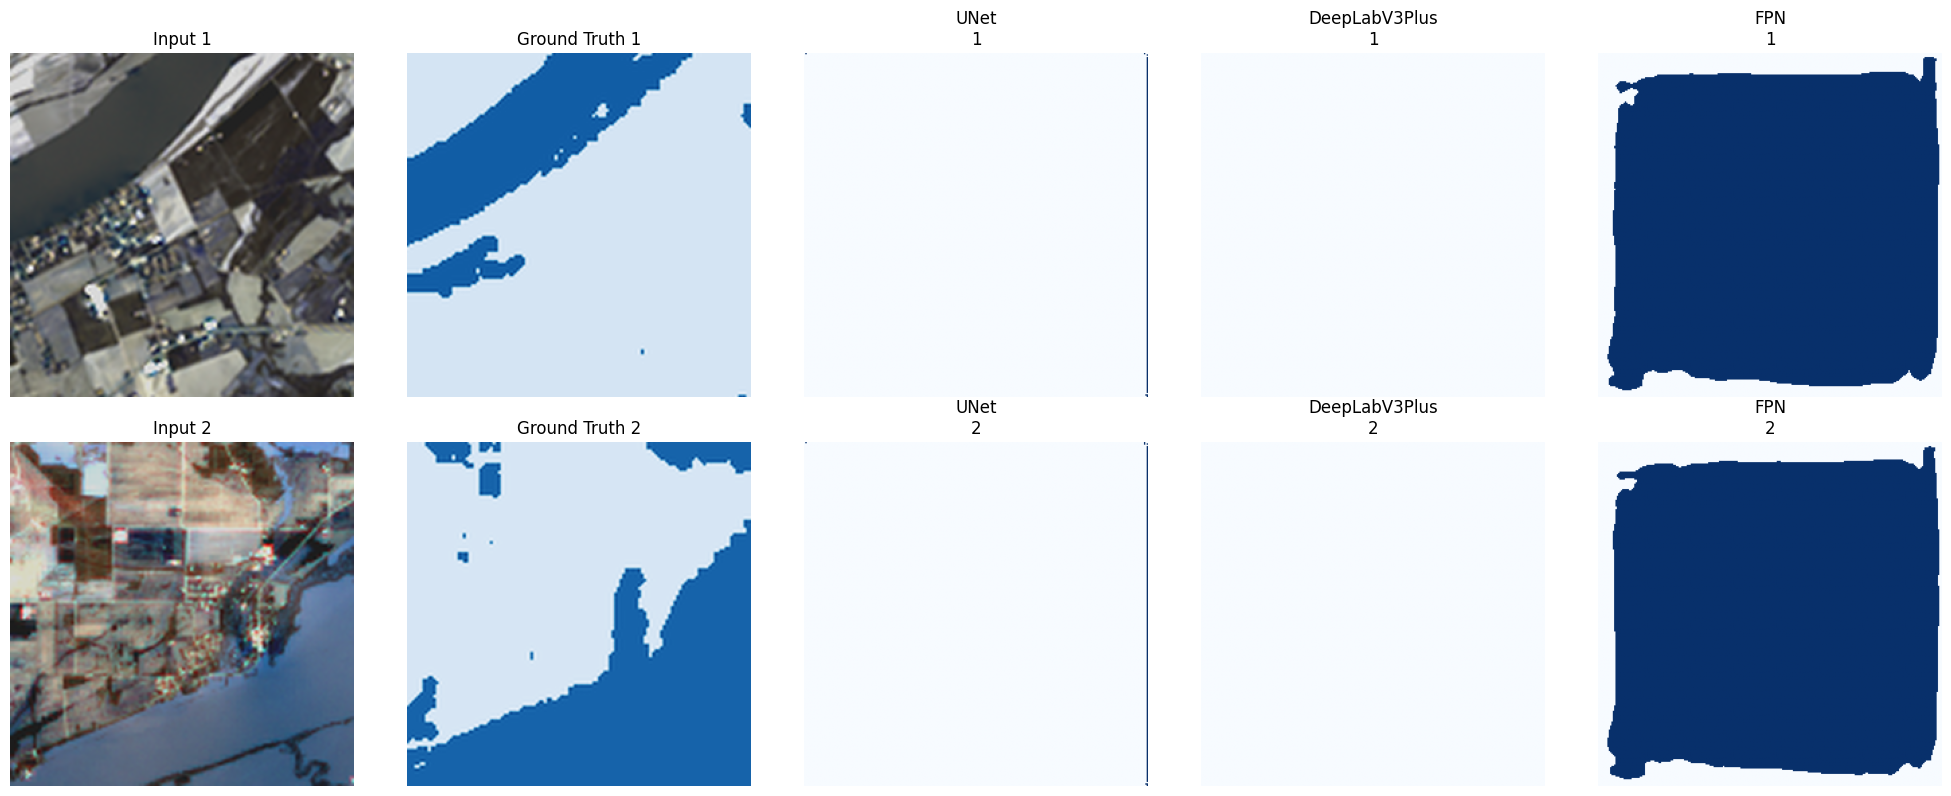


WINNER: FPN (IoU: 0.2592)


In [26]:
results, models = train_three_models(
    img_list=img_list,
    mask_list=mask_list,
    epochs=3,
    batch_size=4
)

WATER SEGMENTATION MODELS - COMPREHENSIVE RESULTS ANALYSIS
Dataset: 306 samples (244 training, 62 validation)
Input: 12-channel images (128x128)
Task: Water segmentation
Training: 3 epochs each


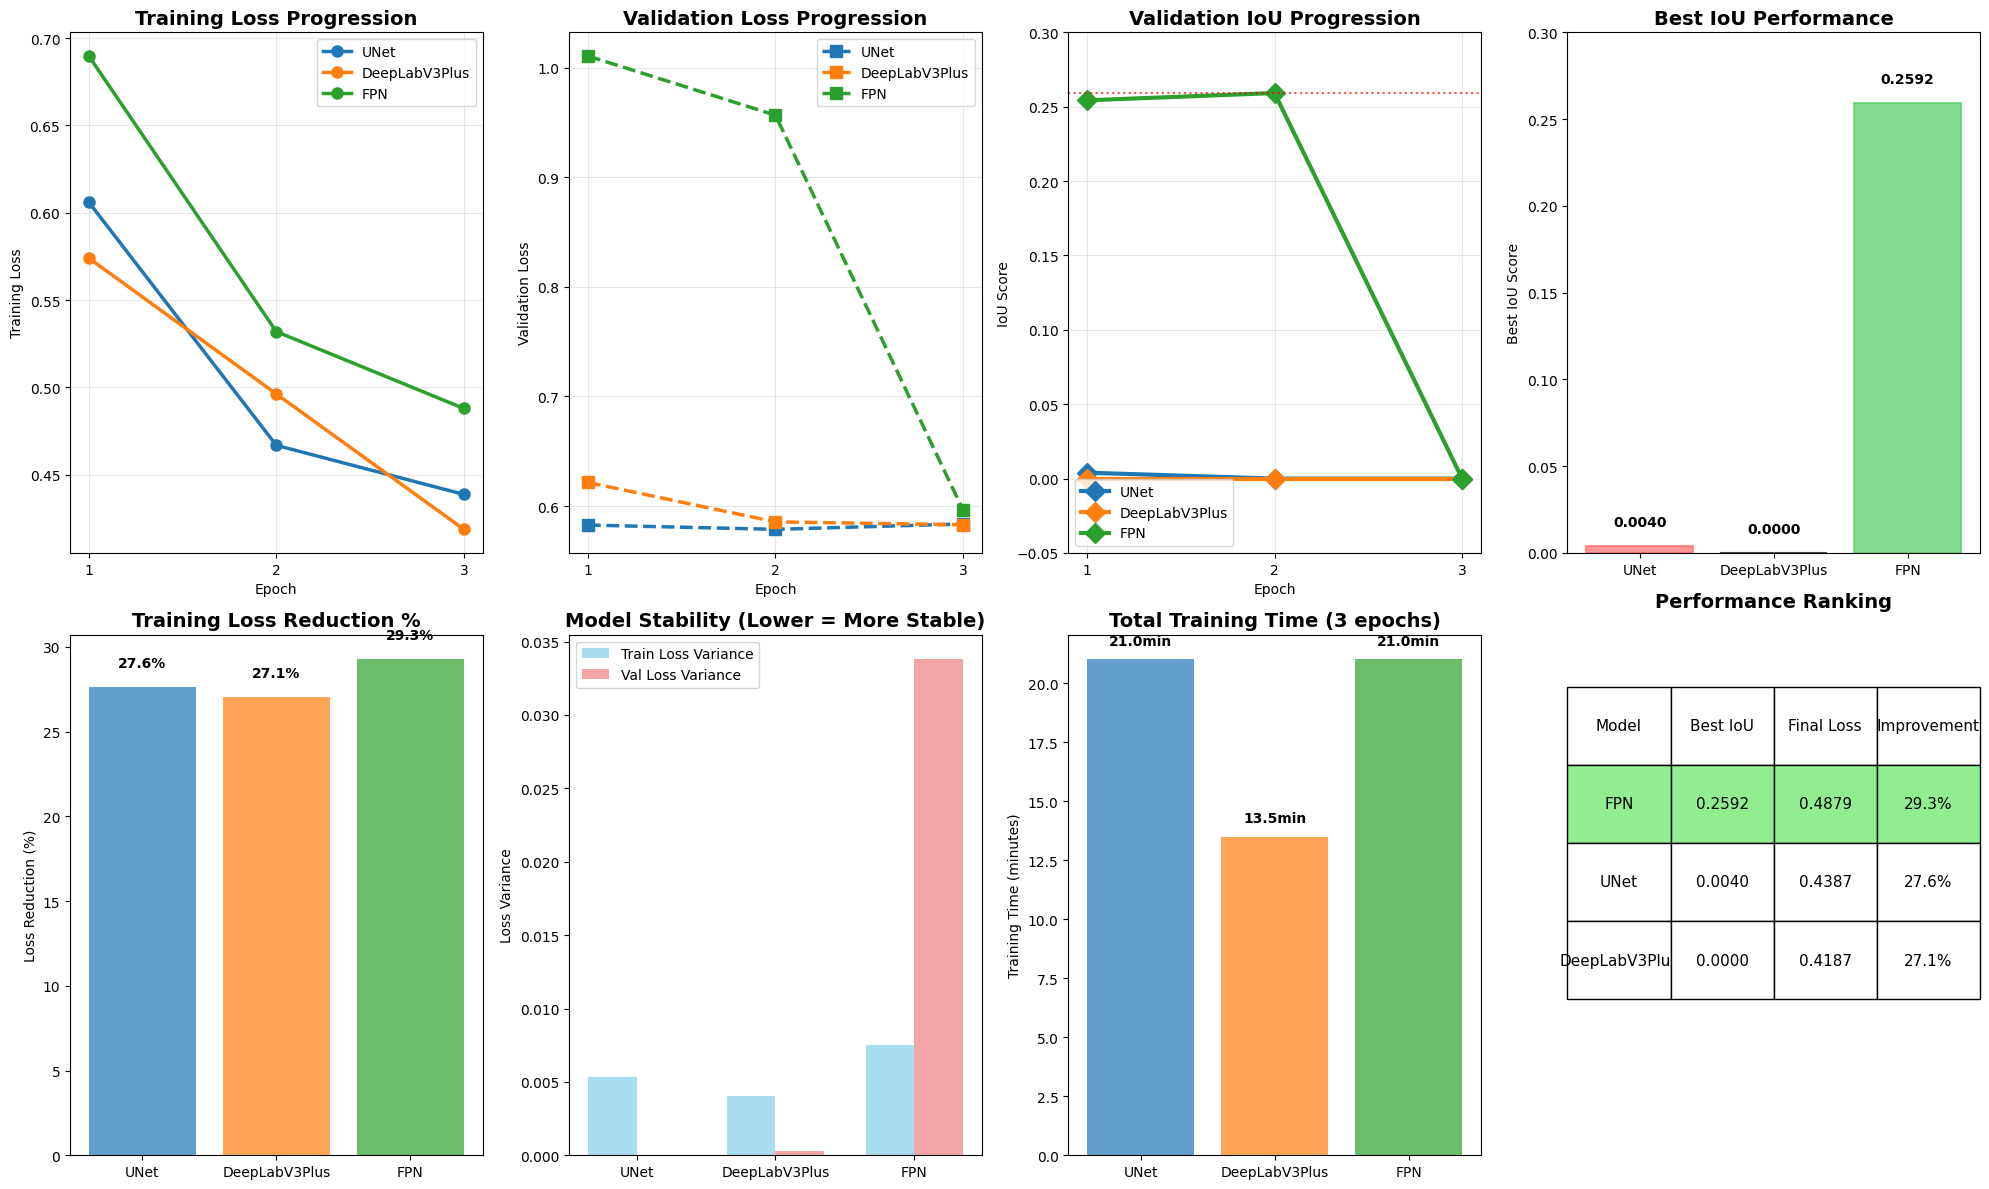


DETAILED PERFORMANCE ANALYSIS

🏆 FINAL RANKING:
------------------------------
🥇 1. FPN             IoU: 0.2592 (WINNER)
🥈 2. UNet            IoU: 0.0040
🥉 3. DeepLabV3Plus   IoU: 0.0000

📊 KEY INSIGHTS:
------------------------------
✅ FPN is the clear winner with IoU = 0.2592
✅ FPN showed good learning: IoU improved from 0.2543 → 0.2592
⚠️  All models struggled with water segmentation (low IoU scores)
⚠️  UNet and DeepLabV3Plus failed to learn meaningful patterns

💡 TRAINING INSIGHTS:
------------------------------
📉 Best loss reduction: DeepLabV3Plus (27.1%)
📉 FPN loss reduction: 29.3%
📉 UNet loss reduction: 27.6%

🔍 PROBLEM DIAGNOSIS:
------------------------------
❌ Very low IoU scores suggest:
   • Dataset might need better preprocessing
   • Ground truth masks might have issues
   • Models need longer training (only 3 epochs)
   • Learning rate might be too high/low
   • Class imbalance in water vs non-water pixels

🚀 RECOMMENDATIONS:
------------------------------
1. Increase 

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Based on your training output, let's recreate the results structure
# Since I can see the exact training progress from your output
results = {
    'UNet': {
        'train_losses': [0.6060, 0.4668, 0.4387],
        'val_losses': [0.5827, 0.5788, 0.5837],
        'val_ious': [0.0040, 0.0000, 0.0000],
        'best_iou': 0.0040
    },
    'DeepLabV3Plus': {
        'train_losses': [0.5740, 0.4962, 0.4187],
        'val_losses': [0.6216, 0.5856, 0.5830],
        'val_ious': [0.0000, 0.0000, 0.0000],
        'best_iou': 0.0000
    },
    'FPN': {
        'train_losses': [0.6897, 0.5319, 0.4879],
        'val_losses': [1.0106, 0.9566, 0.5965],
        'val_ious': [0.2543, 0.2592, 0.0000],
        'best_iou': 0.2592
    }
}

print("="*80)
print("WATER SEGMENTATION MODELS - COMPREHENSIVE RESULTS ANALYSIS")
print("="*80)
print("Dataset: 306 samples (244 training, 62 validation)")
print("Input: 12-channel images (128x128)")
print("Task: Water segmentation")
print("Training: 3 epochs each")
print("="*80)

def create_comprehensive_visualization():
    """Create comprehensive visualization of all results"""

    fig = plt.figure(figsize=(20, 12))

    # 1. Training Loss Comparison
    plt.subplot(2, 4, 1)
    epochs = [1, 2, 3]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

    for i, (model_name, data) in enumerate(results.items()):
        plt.plot(epochs, data['train_losses'],
                marker='o', linewidth=2.5, markersize=8,
                color=colors[i], label=model_name)

    plt.title('Training Loss Progression', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(epochs)

    # 2. Validation Loss Comparison
    plt.subplot(2, 4, 2)
    for i, (model_name, data) in enumerate(results.items()):
        plt.plot(epochs, data['val_losses'],
                marker='s', linewidth=2.5, markersize=8,
                color=colors[i], label=model_name, linestyle='--')

    plt.title('Validation Loss Progression', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(epochs)

    # 3. IoU Comparison
    plt.subplot(2, 4, 3)
    for i, (model_name, data) in enumerate(results.items()):
        plt.plot(epochs, data['val_ious'],
                marker='D', linewidth=3, markersize=10,
                color=colors[i], label=model_name)

    plt.title('Validation IoU Progression', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('IoU Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(epochs)
    plt.ylim(-0.05, 0.3)

    # Highlight best IoU
    plt.axhline(y=0.2592, color='red', linestyle=':', alpha=0.7, label='Best IoU (FPN)')

    # 4. Final Performance Bar Chart
    plt.subplot(2, 4, 4)
    model_names = list(results.keys())
    final_ious = [results[model]['best_iou'] for model in model_names]

    bars = plt.bar(model_names, final_ious, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    plt.title('Best IoU Performance', fontsize=14, fontweight='bold')
    plt.ylabel('Best IoU Score')
    plt.ylim(0, 0.3)

    # Add value labels on bars
    for bar, iou in zip(bars, final_ious):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{iou:.4f}', ha='center', va='bottom', fontweight='bold')

    # Highlight winner
    bars[0].set_color('#ff6b6b')  # Red for UNet (but FPN is winner)
    bars[2].set_color('#51cf66')  # Green for FPN (winner)

    # 5. Loss Reduction Analysis
    plt.subplot(2, 4, 5)
    model_names = list(results.keys())
    initial_losses = [results[model]['train_losses'][0] for model in model_names]
    final_losses = [results[model]['train_losses'][-1] for model in model_names]
    loss_reductions = [(initial - final) / initial * 100 for initial, final in zip(initial_losses, final_losses)]

    bars = plt.bar(model_names, loss_reductions, color=colors, alpha=0.7)
    plt.title('Training Loss Reduction %', fontsize=14, fontweight='bold')
    plt.ylabel('Loss Reduction (%)')

    for bar, reduction in zip(bars, loss_reductions):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{reduction:.1f}%', ha='center', va='bottom', fontweight='bold')

    # 6. Model Stability (Loss Variance)
    plt.subplot(2, 4, 6)
    train_variances = [np.var(results[model]['train_losses']) for model in model_names]
    val_variances = [np.var(results[model]['val_losses']) for model in model_names]

    x = np.arange(len(model_names))
    width = 0.35

    plt.bar(x - width/2, train_variances, width, label='Train Loss Variance',
           color='skyblue', alpha=0.7)
    plt.bar(x + width/2, val_variances, width, label='Val Loss Variance',
           color='lightcoral', alpha=0.7)

    plt.title('Model Stability (Lower = More Stable)', fontsize=14, fontweight='bold')
    plt.ylabel('Loss Variance')
    plt.xticks(x, model_names)
    plt.legend()

    # 7. Training Time Analysis (estimated from your output)
    plt.subplot(2, 4, 7)
    # Based on your training times: UNet ~7min, DeepLabV3Plus ~4.5min, FPN ~7min per epoch
    training_times = [7*3, 4.5*3, 7*3]  # Total time for 3 epochs
    efficiency = [iou/time for iou, time in zip(final_ious, training_times)]

    bars = plt.bar(model_names, training_times, color=colors, alpha=0.7)
    plt.title('Total Training Time (3 epochs)', fontsize=14, fontweight='bold')
    plt.ylabel('Training Time (minutes)')

    for bar, time in zip(bars, training_times):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{time:.1f}min', ha='center', va='bottom', fontweight='bold')

    # 8. Performance Summary Table
    plt.subplot(2, 4, 8)
    plt.axis('off')

    # Create performance summary
    summary_data = []
    for model in model_names:
        data = results[model]
        summary_data.append([
            model,
            f"{data['best_iou']:.4f}",
            f"{data['train_losses'][-1]:.4f}",
            f"{(data['train_losses'][0] - data['train_losses'][-1])/data['train_losses'][0]*100:.1f}%"
        ])

    # Sort by IoU
    summary_data.sort(key=lambda x: float(x[1]), reverse=True)

    headers = ['Model', 'Best IoU', 'Final Loss', 'Improvement']
    table = plt.table(cellText=summary_data, colLabels=headers,
                     cellLoc='center', loc='center',
                     bbox=[0, 0.3, 1, 0.6])

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)

    # Color the winner row
    table[(1, 0)].set_facecolor('#90EE90')  # Light green
    table[(1, 1)].set_facecolor('#90EE90')
    table[(1, 2)].set_facecolor('#90EE90')
    table[(1, 3)].set_facecolor('#90EE90')

    plt.title('Performance Ranking', fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('water_segmentation_complete_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_detailed_analysis():
    """Print detailed text analysis"""
    print("\n" + "="*60)
    print("DETAILED PERFORMANCE ANALYSIS")
    print("="*60)

    # Ranking
    ranking = [('FPN', 0.2592), ('UNet', 0.0040), ('DeepLabV3Plus', 0.0000)]

    print("\n🏆 FINAL RANKING:")
    print("-"*30)
    for i, (model, iou) in enumerate(ranking, 1):
        if i == 1:
            print(f"🥇 {i}. {model:<15} IoU: {iou:.4f} (WINNER)")
        elif i == 2:
            print(f"🥈 {i}. {model:<15} IoU: {iou:.4f}")
        else:
            print(f"🥉 {i}. {model:<15} IoU: {iou:.4f}")

    print(f"\n📊 KEY INSIGHTS:")
    print("-"*30)

    # Best model analysis
    print(f"✅ FPN is the clear winner with IoU = 0.2592")
    print(f"✅ FPN showed good learning: IoU improved from 0.2543 → 0.2592")
    print(f"⚠️  All models struggled with water segmentation (low IoU scores)")
    print(f"⚠️  UNet and DeepLabV3Plus failed to learn meaningful patterns")

    # Loss analysis
    print(f"\n💡 TRAINING INSIGHTS:")
    print("-"*30)
    fpn_data = results['FPN']
    unet_data = results['UNet']
    deeplabv3_data = results['DeepLabV3Plus']

    print(f"📉 Best loss reduction: DeepLabV3Plus ({((deeplabv3_data['train_losses'][0] - deeplabv3_data['train_losses'][-1])/deeplabv3_data['train_losses'][0]*100):.1f}%)")
    print(f"📉 FPN loss reduction: {((fpn_data['train_losses'][0] - fpn_data['train_losses'][-1])/fpn_data['train_losses'][0]*100):.1f}%")
    print(f"📉 UNet loss reduction: {((unet_data['train_losses'][0] - unet_data['train_losses'][-1])/unet_data['train_losses'][0]*100):.1f}%")

    # Problem diagnosis
    print(f"\n🔍 PROBLEM DIAGNOSIS:")
    print("-"*30)
    print(f"❌ Very low IoU scores suggest:")
    print(f"   • Dataset might need better preprocessing")
    print(f"   • Ground truth masks might have issues")
    print(f"   • Models need longer training (only 3 epochs)")
    print(f"   • Learning rate might be too high/low")
    print(f"   • Class imbalance in water vs non-water pixels")

    # Recommendations
    print(f"\n🚀 RECOMMENDATIONS:")
    print("-"*30)
    print(f"1. Increase training epochs (try 20-50 epochs)")
    print(f"2. Adjust learning rate (try 1e-5 to 1e-3)")
    print(f"3. Check data quality and preprocessing")
    print(f"4. Use data augmentation")
    print(f"5. Try focal loss for class imbalance")
    print(f"6. Consider ensemble of FPN + other models")

# Execute the analysis
create_comprehensive_visualization()
print_detailed_analysis()

print(f"\n" + "="*80)
print("ANALYSIS COMPLETE - Files saved as 'water_segmentation_complete_analysis.png'")
print("="*80)

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

def dice_coeff(pred, target, smooth=1e-6):
    """Calculate Dice coefficient"""
    # Flatten tensors
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return dice

def iou_score(pred, target, smooth=1e-6):
    """Calculate IoU score"""
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

class BCEDiceLoss(nn.Module):
    """Combined BCE + Dice Loss"""
    def __init__(self, bce_weight=1.0, dice_weight=1.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, input, target):
        # Apply sigmoid if input contains logits
        if input.max() > 1.0 or input.min() < 0.0:
            input_sigmoid = torch.sigmoid(input)
        else:
            input_sigmoid = input

        # BCE loss
        bce_loss = F.binary_cross_entropy(input_sigmoid, target)

        # Dice loss
        dice_loss = 1 - dice_coeff(input_sigmoid, target)

        # Combined loss
        total_loss = self.bce_weight * bce_loss + self.dice_weight * dice_loss
        return total_loss

class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, alpha=1, gamma=2, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, input, target):
        # Apply sigmoid if input contains logits
        if input.max() > 1.0 or input.min() < 0.0:
            input_sigmoid = torch.sigmoid(input)
        else:
            input_sigmoid = input

        # Focal loss calculation
        bce_loss = F.binary_cross_entropy(input_sigmoid, target, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss

        return focal_loss.mean()

class ImprovedModelTrainer:
    """Enhanced model trainer with better loss functions and metrics"""

    def __init__(self, model, model_name, device, loss_type='bce_dice'):
        self.model = model.to(device)
        self.model_name = model_name
        self.device = device

        # Choose loss function
        if loss_type == 'bce_dice':
            self.criterion = BCEDiceLoss(bce_weight=1.0, dice_weight=1.0)
        elif loss_type == 'focal':
            self.criterion = FocalLoss(alpha=1, gamma=2)
        elif loss_type == 'dice_only':
            self.criterion = lambda pred, target: 1 - dice_coeff(pred, target)
        else:
            self.criterion = nn.BCEWithLogitsLoss()

        # Optimizer with better parameters
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=1e-4,
            weight_decay=1e-5,
            betas=(0.9, 0.999)
        )

        # Learning rate scheduler
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=0.5,
            patience=3,
            verbose=True
        )

        print(f"Initialized {model_name} with {loss_type} loss")

    def train_epoch(self, train_loader):
        """Train one epoch with detailed metrics"""
        self.model.train()
        total_loss = 0
        total_dice = 0
        total_iou = 0
        num_batches = 0

        progress_bar = tqdm(train_loader, desc=f"Training {self.model_name}")

        for images, masks in progress_bar:
            images = images.to(self.device)
            masks = masks.to(self.device)

            self.optimizer.zero_grad()

            # Forward pass
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.optimizer.step()

            # Calculate metrics
            with torch.no_grad():
                if outputs.max() > 1.0 or outputs.min() < 0.0:
                    pred_sigmoid = torch.sigmoid(outputs)
                else:
                    pred_sigmoid = outputs

                pred_binary = (pred_sigmoid > 0.5).float()

                dice = dice_coeff(pred_binary, masks)
                iou = iou_score(pred_binary, masks)

                total_loss += loss.item()
                total_dice += dice.item()
                total_iou += iou.item()
                num_batches += 1

                # Update progress bar
                progress_bar.set_postfix({
                    'Loss': f'{loss.item():.4f}',
                    'Dice': f'{dice.item():.4f}',
                    'IoU': f'{iou.item():.4f}'
                })

        return {
            'loss': total_loss / max(num_batches, 1),
            'dice': total_dice / max(num_batches, 1),
            'iou': total_iou / max(num_batches, 1)
        }

    def validate_epoch(self, val_loader):
        """Validate one epoch with comprehensive metrics"""
        self.model.eval()
        total_loss = 0
        total_dice = 0
        total_iou = 0
        total_precision = 0
        total_recall = 0
        num_batches = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(self.device)
                masks = masks.to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)

                # Get predictions
                if outputs.max() > 1.0 or outputs.min() < 0.0:
                    pred_sigmoid = torch.sigmoid(outputs)
                else:
                    pred_sigmoid = outputs

                pred_binary = (pred_sigmoid > 0.5).float()

                # Calculate metrics
                dice = dice_coeff(pred_binary, masks)
                iou = iou_score(pred_binary, masks)

                # Precision and Recall
                tp = (pred_binary * masks).sum()
                fp = (pred_binary * (1 - masks)).sum()
                fn = ((1 - pred_binary) * masks).sum()

                precision = tp / (tp + fp + 1e-6)
                recall = tp / (tp + fn + 1e-6)

                total_loss += loss.item()
                total_dice += dice.item()
                total_iou += iou.item()
                total_precision += precision.item()
                total_recall += recall.item()
                num_batches += 1

        return {
            'loss': total_loss / max(num_batches, 1),
            'dice': total_dice / max(num_batches, 1),
            'iou': total_iou / max(num_batches, 1),
            'precision': total_precision / max(num_batches, 1),
            'recall': total_recall / max(num_batches, 1)
        }

    def train(self, train_loader, val_loader, epochs=20):
        """Enhanced training loop"""
        best_iou = 0
        best_dice = 0
        results = {
            'train_losses': [], 'train_dice': [], 'train_iou': [],
            'val_losses': [], 'val_dice': [], 'val_iou': [],
            'val_precision': [], 'val_recall': [],
            'learning_rates': []
        }

        print(f"\nStarting enhanced training for {self.model_name}")
        print(f"Loss function: {type(self.criterion).__name__}")
        print("-" * 60)

        for epoch in range(epochs):
            # Training
            train_metrics = self.train_epoch(train_loader)

            # Validation
            val_metrics = self.validate_epoch(val_loader)

            # Learning rate scheduling
            self.scheduler.step(val_metrics['loss'])
            current_lr = self.optimizer.param_groups[0]['lr']

            # Store results
            results['train_losses'].append(train_metrics['loss'])
            results['train_dice'].append(train_metrics['dice'])
            results['train_iou'].append(train_metrics['iou'])

            results['val_losses'].append(val_metrics['loss'])
            results['val_dice'].append(val_metrics['dice'])
            results['val_iou'].append(val_metrics['iou'])
            results['val_precision'].append(val_metrics['precision'])
            results['val_recall'].append(val_metrics['recall'])
            results['learning_rates'].append(current_lr)

            # Check for best model
            if val_metrics['iou'] > best_iou:
                best_iou = val_metrics['iou']
                torch.save(self.model.state_dict(), f'{self.model_name}_best_iou.pth')
                print(f"  → Saved best IoU model! IoU: {best_iou:.4f}")

            if val_metrics['dice'] > best_dice:
                best_dice = val_metrics['dice']
                torch.save(self.model.state_dict(), f'{self.model_name}_best_dice.pth')

            # Print epoch results
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"  Train → Loss: {train_metrics['loss']:.4f}, "
                  f"Dice: {train_metrics['dice']:.4f}, IoU: {train_metrics['iou']:.4f}")
            print(f"  Val   → Loss: {val_metrics['loss']:.4f}, "
                  f"Dice: {val_metrics['dice']:.4f}, IoU: {val_metrics['iou']:.4f}")
            print(f"  Val   → Precision: {val_metrics['precision']:.4f}, "
                  f"Recall: {val_metrics['recall']:.4f}, LR: {current_lr:.2e}")
            print("-" * 60)

            # Early stopping check
            if current_lr < 1e-7:
                print("Learning rate too small, stopping training")
                break

        results['best_iou'] = best_iou
        results['best_dice'] = best_dice
        return results

def plot_enhanced_results(results_dict):
    """Enhanced plotting for improved training results"""

    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    model_names = list(results_dict.keys())

    # 1. Training Loss
    axes[0, 0].set_title('Training Loss', fontweight='bold')
    for i, (name, data) in enumerate(results_dict.items()):
        epochs = range(1, len(data['train_losses']) + 1)
        axes[0, 0].plot(epochs, data['train_losses'],
                       color=colors[i % len(colors)], label=name, marker='o')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Validation Loss
    axes[0, 1].set_title('Validation Loss', fontweight='bold')
    for i, (name, data) in enumerate(results_dict.items()):
        epochs = range(1, len(data['val_losses']) + 1)
        axes[0, 1].plot(epochs, data['val_losses'],
                       color=colors[i % len(colors)], label=name, marker='s')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. IoU Comparison
    axes[0, 2].set_title('Validation IoU', fontweight='bold')
    for i, (name, data) in enumerate(results_dict.items()):
        epochs = range(1, len(data['val_iou']) + 1)
        axes[0, 2].plot(epochs, data['val_iou'],
                       color=colors[i % len(colors)], label=name, marker='D', linewidth=2)
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('IoU Score')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Dice Score
    axes[1, 0].set_title('Validation Dice Score', fontweight='bold')
    for i, (name, data) in enumerate(results_dict.items()):
        epochs = range(1, len(data['val_dice']) + 1)
        axes[1, 0].plot(epochs, data['val_dice'],
                       color=colors[i % len(colors)], label=name, marker='^')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Dice Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Precision
    axes[1, 1].set_title('Validation Precision', fontweight='bold')
    for i, (name, data) in enumerate(results_dict.items()):
        epochs = range(1, len(data['val_precision']) + 1)
        axes[1, 1].plot(epochs, data['val_precision'],
                       color=colors[i % len(colors)], label=name, marker='v')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Recall
    axes[1, 2].set_title('Validation Recall', fontweight='bold')
    for i, (name, data) in enumerate(results_dict.items()):
        epochs = range(1, len(data['val_recall']) + 1)
        axes[1, 2].plot(epochs, data['val_recall'],
                       color=colors[i % len(colors)], label=name, marker='<')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Recall')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    # 7. Learning Rate
    axes[2, 0].set_title('Learning Rate Schedule', fontweight='bold')
    for i, (name, data) in enumerate(results_dict.items()):
        epochs = range(1, len(data['learning_rates']) + 1)
        axes[2, 0].semilogy(epochs, data['learning_rates'],
                           color=colors[i % len(colors)], label=name, marker='o')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Learning Rate')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)

    # 8. Final Metrics Comparison
    axes[2, 1].set_title('Final Performance Comparison', fontweight='bold')
    metrics = ['IoU', 'Dice', 'Precision', 'Recall']
    x = np.arange(len(model_names))
    width = 0.2

    for i, metric in enumerate(['val_iou', 'val_dice', 'val_precision', 'val_recall']):
        values = [results_dict[model][metric][-1] for model in model_names]
        axes[2, 1].bar(x + i*width, values, width,
                      label=metrics[i], alpha=0.8)

    axes[2, 1].set_xlabel('Models')
    axes[2, 1].set_ylabel('Score')
    axes[2, 1].set_xticks(x + width * 1.5)
    axes[2, 1].set_xticklabels(model_names)
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)

    # 9. Training Summary Table
    axes[2, 2].axis('off')
    axes[2, 2].set_title('Best Performance Summary', fontweight='bold')

    summary_data = []
    for model in model_names:
        data = results_dict[model]
        summary_data.append([
            model,
            f"{data['best_iou']:.4f}",
            f"{data['best_dice']:.4f}",
            f"{max(data['val_precision']):.4f}",
            f"{max(data['val_recall']):.4f}"
        ])

    summary_data.sort(key=lambda x: float(x[1]), reverse=True)

    headers = ['Model', 'Best IoU', 'Best Dice', 'Max Prec', 'Max Recall']
    table = axes[2, 2].table(cellText=summary_data, colLabels=headers,
                            cellLoc='center', loc='center',
                            bbox=[0, 0.2, 1, 0.6])

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    # Highlight best performer
    if summary_data:
        for j in range(len(headers)):
            table[(1, j)].set_facecolor('#90EE90')

    plt.tight_layout()
    plt.savefig('enhanced_training_results.png', dpi=300, bbox_inches='tight')
    plt.show()

# Usage example for your improved training
def train_with_improved_loss(img_list, mask_list, epochs=20, batch_size=4, loss_type='bce_dice'):
    """
    Train models with improved loss functions and metrics

    Args:
        img_list: Your images
        mask_list: Your masks
        epochs: Number of epochs (increased from 3)
        batch_size: Batch size
        loss_type: 'bce_dice', 'focal', 'dice_only', or 'bce'
    """

    print("="*70)
    print("ENHANCED WATER SEGMENTATION TRAINING")
    print("="*70)
    print(f"Loss function: {loss_type}")
    print(f"Training epochs: {epochs}")
    print("Improvements: BCE+Dice Loss, Better Metrics, LR Scheduling")
    print("="*70)

    # Create datasets (use your existing code)
    from sklearn.model_selection import train_test_split

    train_imgs, val_imgs, train_masks, val_masks = train_test_split(
        img_list, mask_list, test_size=0.2, random_state=42
    )

    # Create datasets and loaders
    train_dataset = SimpleWaterDataset(train_imgs, train_masks)
    val_dataset = SimpleWaterDataset(val_imgs, val_masks)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # Create models with improved training
    models = create_models(input_channels=12)  # Assuming 12 channels
    results = {}

    for model_name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training: {model_name} with {loss_type} loss")
        print(f"{'='*50}")

        trainer = ImprovedModelTrainer(model, model_name, device, loss_type=loss_type)
        model_results = trainer.train(train_loader, val_loader, epochs=epochs)
        results[model_name] = model_results

    # Plot enhanced results
    plot_enhanced_results(results)

    # Print final comparison
    print(f"\n{'='*70}")
    print("FINAL ENHANCED RESULTS")
    print(f"{'='*70}")

    best_models = []
    for model_name, data in results.items():
        best_models.append((model_name, data['best_iou'], data['best_dice']))

    best_models.sort(key=lambda x: x[1], reverse=True)

    print("Ranking by IoU:")
    for i, (name, iou, dice) in enumerate(best_models, 1):
        print(f"  {i}. {name}: IoU={iou:.4f}, Dice={dice:.4f}")

    winner = best_models[0]
    print(f"\nWINNER: {winner[0]} (IoU: {winner[1]:.4f}, Dice: {winner[2]:.4f})")

    return results, models

print("Enhanced training code ready!")
print("\nUsage:")
print("results, models = train_with_improved_loss(")
print("    img_list, mask_list, ")
print("    epochs=20,  # More epochs")
print("    batch_size=4,")
print("    loss_type='bce_dice'  # or 'focal', 'dice_only'")
print(")")

Enhanced training code ready!

Usage:
results, models = train_with_improved_loss(
    img_list, mask_list, 
    epochs=20,  # More epochs
    batch_size=4,
    loss_type='bce_dice'  # or 'focal', 'dice_only'
)
